# Wine Quality Prediction

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import  matplotlib.pyplot as plt

from sklearn.datasets import load_wine

In [2]:
# load data
wine = load_wine()

X = wine.data
y = wine.target

In [3]:
# 
df  = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = wine.target
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [4]:
# Basic inspections
print("Basic inspection result\n")
print(f"Shape : {df.shape}")
print(f"Columns: {list(df.columns)}")

print("\nFirst 5 rows")
print(df.head())

print("\nSummary statistic")
print(df.describe().round(2))

Basic inspection result

Shape : (178, 14)
Columns: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']

First 5 rows
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24 

In [5]:
# Missing Values
print("Missing Values")
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'count':missing,
    'percentage':missing_pct
})
print(missing_df[missing_df['count'] > 0].sort_values('percentage', ascending=False))

Missing Values
Empty DataFrame
Columns: [count, percentage]
Index: []


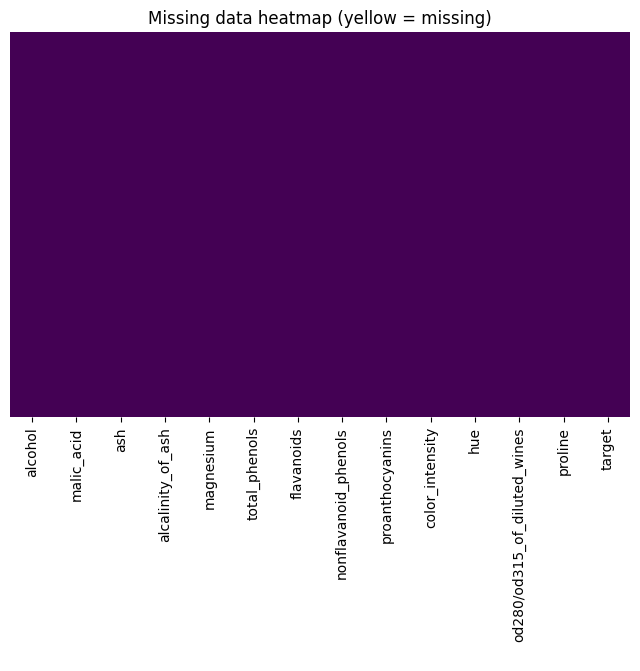

In [6]:
# plot missing data
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis',yticklabels=False)
plt.title("Missing data heatmap (yellow = missing)")
plt.xlabel(" ")
plt.ylabel("")
plt.show()

In [7]:
# 4. Target Distribution
TARGET = 'target'
print("Target Distribution")
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True).round(3))

Target Distribution
target
1    71
0    59
2    48
Name: count, dtype: int64
target
1    0.399
0    0.331
2    0.270
Name: proportion, dtype: float64


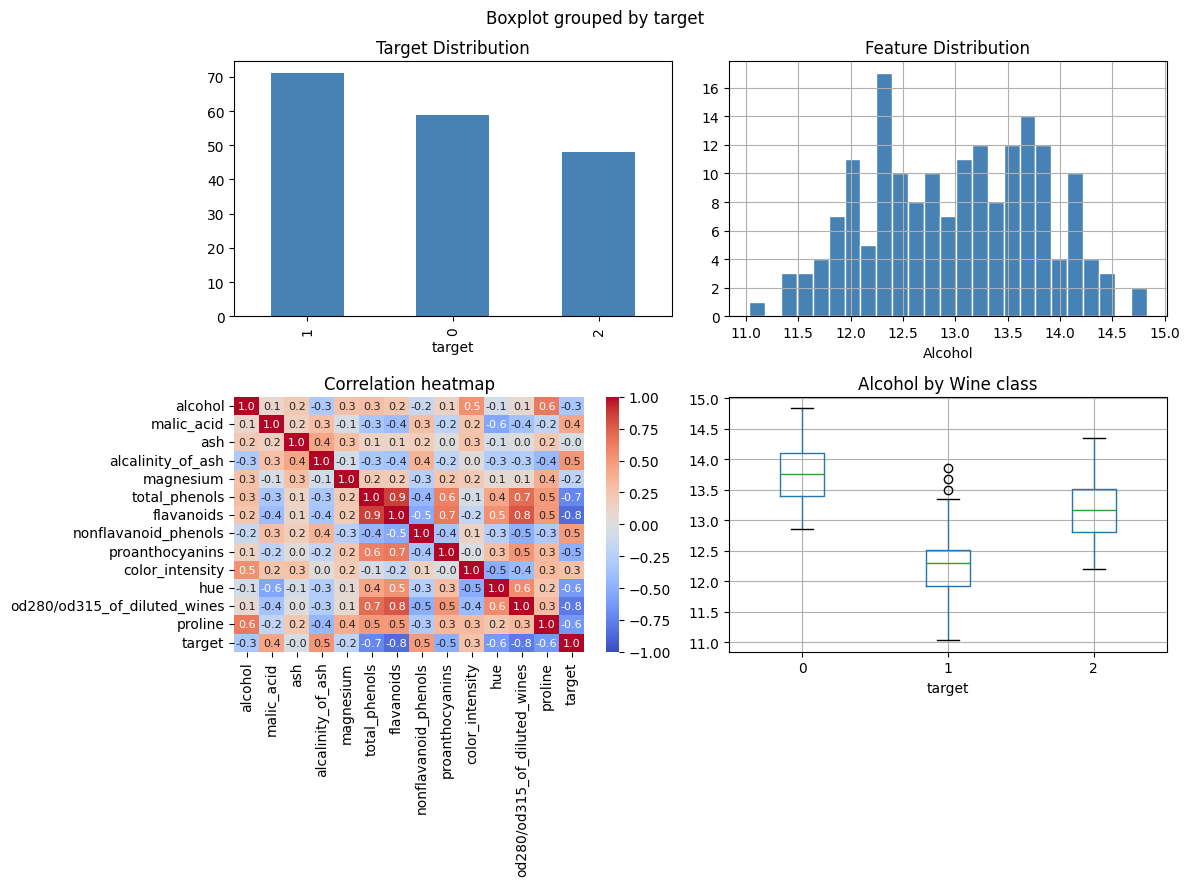

In [8]:
# 5. Visualization

fig, axes = plt.subplots(2,2, figsize=(12,9))

# target distribution
df[TARGET].value_counts().plot(kind='bar',ax=axes[0,0], color='steelblue')
axes[0,0].set_title("Target Distribution")

# feature disbribution (alcohol)
df['alcohol'].dropna().hist(ax=axes[0,1], bins=25, color='steelblue', edgecolor='white')
axes[0,1].set_title("Feature Distribution")
axes[0, 1].set_xlabel("Alcohol")

# correlation headmap (numerical column)
num_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[num_cols].corr(),
            annot=True,
            fmt='.1f', 
            cmap='coolwarm', 
            ax=axes[1,0], 
            vmin=-1,vmax=1,
           annot_kws={"size":8})
axes[1,0].set_title("Correlation heatmap")

# Feature vs target (alcohol v wine class)
df.boxplot(column='alcohol', by=TARGET, ax=axes[1,1])
axes[1,1].set_title('Alcohol by Wine class')

plt.tight_layout()
plt.show()

## EDA Findings
1. How many rows and columns?
   - 178 rows
   - 14 columns
2. Which columns have missing data and how much?
   - No Missing Values
3. Is the target class balanced or imbalanced?
   - The class are fairly balanced
   - Class 1 hass slightly more samples
   - No severe imbalance  problem exists
4. Which features appear most correlate with the target?
    - `alcalinity_of_ash` -> 0.52
    - `nonflavanoid_phenols` -> 0.5 
6. Which columns are you going to DROP and WHY?
    - No columns need to be dropped

## Feature Engineering and Pipeline

In [9]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import  StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

In [10]:
# 1. select and clean columns
df_clean = df.copy()

In [11]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [12]:
# Separating features from target
TARGET = "target"

X = df_clean.drop(columns=TARGET)
y = df_clean[TARGET]

In [13]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

In [14]:
y.info()

<class 'pandas.Series'>
RangeIndex: 178 entries, 0 to 177
Series name: target
Non-Null Count  Dtype
--------------  -----
178 non-null    int64
dtypes: int64(1)
memory usage: 1.5 KB


In [15]:
print(f"Features remaining: {list[X.columns]}")
print(f"Shape: {X.shape}")
print(f"The Target : {TARGET}")

Features remaining: list[Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='str')]
Shape: (178, 13)
The Target : target


In [16]:
# splitting then preprocessing
# stratiy ensure that your training and test
# sets maintain the same class proportion as the original dataset
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.2,
                                                    random_state=42,
                                                   stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (142, 13) | Test: (36, 13)


In [17]:
# Building the pipeline
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])


pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

## Evaluation

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
# accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 97.22%


In [20]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [21]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


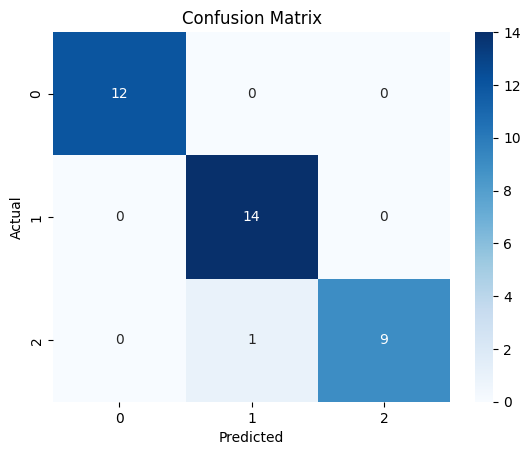

In [22]:
# plot confusion matric

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Cross Validation

In [23]:
# cross validation
scores = cross_val_score(pipe, X, y, cv=5)

print(f"CV Mean Accuracy: {scores.mean():.2%}")
print(f"CV Std: {scores.std():.2f}")

CV Mean Accuracy: 98.32%
CV Std: 0.01
